In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as ax
from matplotlib.animation import FuncAnimation

In [11]:
# Reading and shaping data
url = 'https://media.geeksforgeeks.org/wp-content/uploads/20240320114716/data_for_lr.csv'
data = pd.read_csv(url)
data

# Drop missing values
data = data.dropna()

# training dataset and labels
train_input = np.array(data.x[0:500]).reshape(500, 1)
train_output = np.array(data.y[0:500]).reshape(500, 1)

# valid dataset and labels
test_input = np.array(data.x[500:700]).reshape(199, 1)
test_output = np.array(data.y[500:700]).reshape(199, 1)

In [17]:
class LinearRegression:
    def __init__(self):
        
        # Linear model parameters
        self.parameters = {}
    
    def forward_propagation(self, train_input):
        
        # Outputting predicted outputs
        m = self.parameters['m']
        c = self.parameters['c']
        predictions = np.multiply(m, train_input) + c
        return predictions

    def cost_function(self, predictions, train_output):
        
        # Mean Squared Error cost function
        cost = np.mean((train_output - predictions) ** 2)
        return cost

    def backward_propagation(self, train_input, train_output, predictions):
        
        # Calculating gradient of loss function
        derivatives = {}
        df = (predictions - train_output)
        dm = 2 * np.mean(np.multiply(train_input, df))
        dc = 2 * np.mean(df)
        derivatives['dm'] = dm
        derivatives['dc'] = dc
        return derivatives

    def update_parameters(self, derivatives, learning_rate):
        
        # Updating model parameters based on gradient
        self.parameters['m'] = self.parameters['m'] - learning_rate * derivatives['dm']
        self.parameters['c'] = self.parameters['c'] - learning_rate * derivatives['dc']
        
    def train(self, train_input, train_output, learning_rate, iters):
        
        # Initialize random parameters
        self.parameters['m'] = np.random.uniform(0, 1) * -1
        self.parameters['c'] = np.random.uniform(0, 1) * -1
        
        # Initialize loss
        self.loss = []
        
        # Initialize figure and axis for animation 
        fig, ax = plt.subplots() 
        x_vals = np.linspace(min(train_input), max(train_input), 100) 
        line, = ax.plot(x_vals, self.parameters['m'] * x_vals +
                        self.parameters['c'], color='red', label='Regression Line') 
        ax.scatter(train_input, train_output, marker='o', 
                color='green', label='Training Data') 

        # Set y-axis limits to exclude negative values 
        ax.set_ylim(0, max(train_output) + 1)
        
        def update(frame):
            
            # Forward propagation
            predictions = self.forward_propagation(train_input)
            
            # Cost function
            cost = self.cost_function(predictions, train_output)
            
            # Back propagation
            derivatives = self.backward_propagation(train_input, train_output, predictions)
            
            # Update parameters
            self.update_parameters(derivatives, learning_rate)
            
            # Update the regression line
            line.set_ydata(self.parameters['m'] * x_vals + self.parameters['c'])
            
            # Append loss and print
            self.loss.append(cost)
            print("Iteration = {}, Loss = {}".format(frame + 1, cost))
            
            return line,

        ani = FuncAnimation(fig, update, frames=iters, interval=200, blit=True)
        
        # Save the animation as a video file (e.g., MP4) 
        ani.save('linear_regression_A.gif', writer='ffmpeg') 

        plt.xlabel('Input') 
        plt.ylabel('Output') 
        plt.title('Linear Regression') 
        plt.legend() 
        plt.show() 

        return self.parameters, self.loss
            
            
            

Iteration = 1, Loss = 10563.17686359343
Iteration = 1, Loss = 1279.9671295456271
Iteration = 1, Loss = 161.23931934402427
Iteration = 1, Loss = 26.420432281677552
Iteration = 2, Loss = 10.17327800909451
Iteration = 3, Loss = 8.215307915150232
Iteration = 4, Loss = 7.979340020251688
Iteration = 5, Loss = 7.95089213143714
Iteration = 6, Loss = 7.947452662853536
Iteration = 7, Loss = 7.947026982193178
Iteration = 8, Loss = 7.946964496902679
Iteration = 9, Loss = 7.946945781733728
Iteration = 10, Loss = 7.9469323424675995
Iteration = 11, Loss = 7.946919540131903
Iteration = 12, Loss = 7.946906815679866
Iteration = 13, Loss = 7.9468941017401535
Iteration = 14, Loss = 7.946881390193678
Iteration = 15, Loss = 7.946868680061878
Iteration = 16, Loss = 7.946855971226722
Iteration = 17, Loss = 7.9468432636738715
Iteration = 18, Loss = 7.946830557401479
Iteration = 19, Loss = 7.9468178524092155
Iteration = 20, Loss = 7.946805148696925


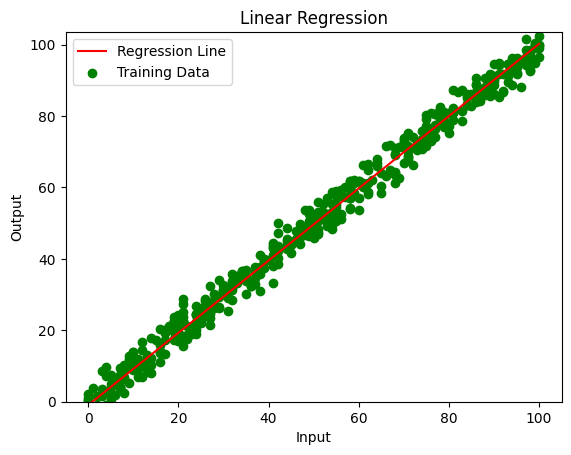

In [19]:
linear_reg = LinearRegression()
parameters, loss = linear_reg.train(train_input, train_output, 0.0001, 20)